# Advanced Machine Learning Midterm Exam
## Customer Offer Dataset
### Dirks Wright

In [2]:
### import libraries
import pandas as pd
import numpy as np
from plotnine import *
import sweetviz as sv
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from catboost import CatBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold


In [3]:
### load dataset
df = pd.read_csv('midterm_train.csv')
df.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


## Exploratory Data Analysis

In [4]:
### sweetviz report
report = sv.analyze(df)
report.show_html('midterm_report.html')

                                             |          | [  0%]   00:00 -> (? left)

Report midterm_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### SweetViz Summary

Based on the sweetviz report, this dataset is imbalanced with majority of customers declining the product. Additionally, customers werre primarily between 30 and 50 years of age. More married customers were included, than single or divorced.

As for associations, `economic_activity_change` appears to be strongly associated to the various economic index and confidence measures. The last contact month also appears to share a similar association trend.

The target variable `accepted_offer` doesn't appear to have strong associations with any of the variables.

In [5]:
### summary statistics
df.describe()

,id,customer_age,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,20612.919423,40.016813,257.355387,2.556601,961.748892,0.173445,0.077132,93.574951,-40.508273,3.614729,5166.787681,0.112747,0.136510,0.037511
std,11872.660725,10.421766,256.687433,2.751165,188.697125,0.496422,1.572468,0.579559,4.628221,1.737144,72.459588,0.316288,0.343334,0.190014
min,0.000000,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000
25%,10373.250000,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,0.000000
50%,20610.500000,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000,0.000000
75%,30858.750000,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000,0.000000
max,41187.000000,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000


In [6]:
### missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
id                           0
customer_age                 0
occupation_type              0
relationship_status          0
education_background         0
has_credit_issue             0
mortgage_status              0
personal_loan_status         0
last_contact_month           0
day_of_week                  0
contact_time_minutes         0
contact_attempt_count        0
days_since_prior_contact     0
prior_contact_count          0
prior_outcome_status         0
economic_activity_change     0
consumer_price_index         0
consumer_confidence_index    0
reference_interest_rate      0
employment_level_index       0
accepted_offer               0
is_repeat_customer           0
recent_contact_flag          0
dtype: int64


The missing-value check confirms this notebook does not have to deal with missing data

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

### Numeric Visualizations

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



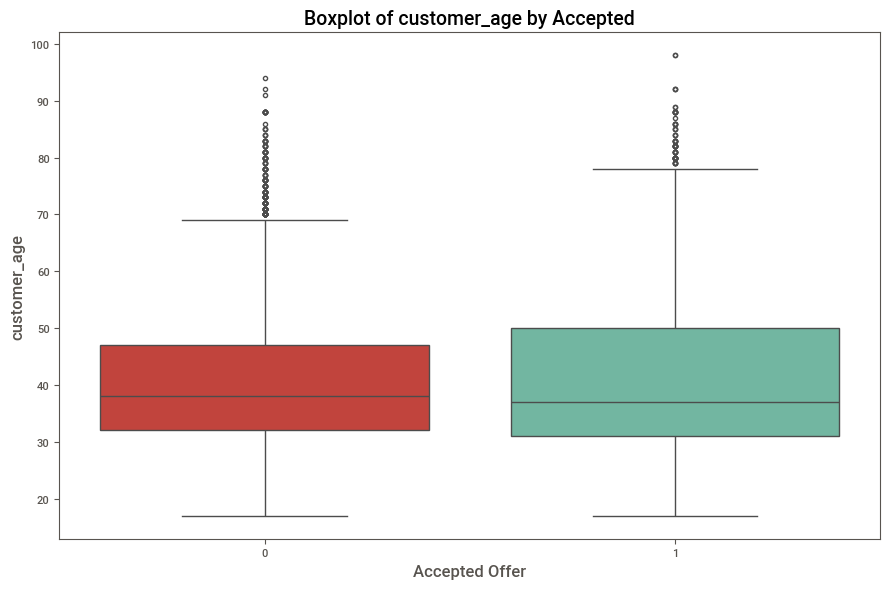

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



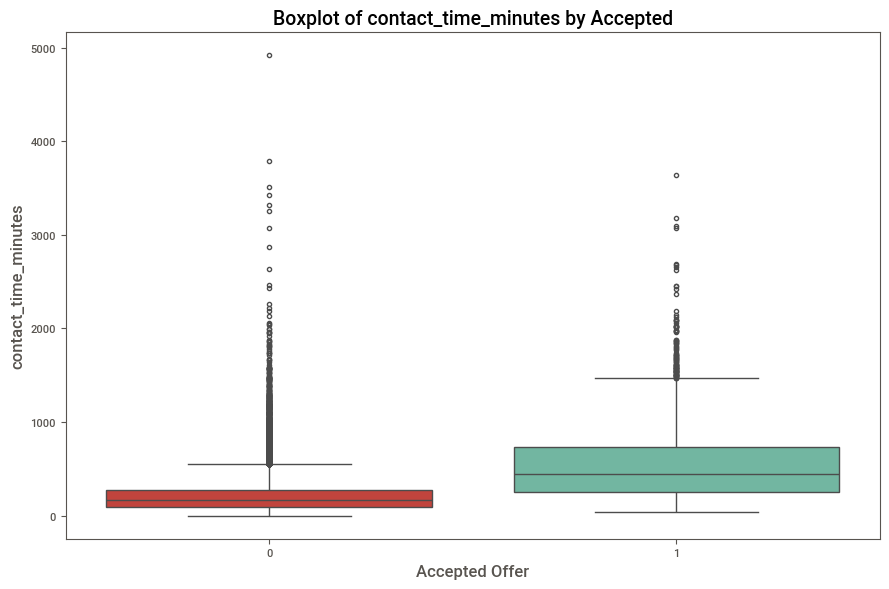

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



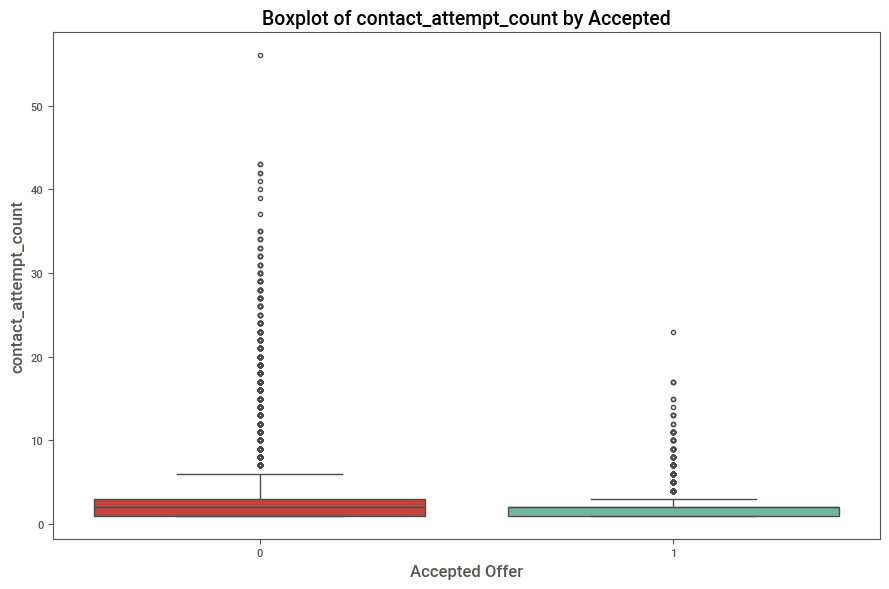

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



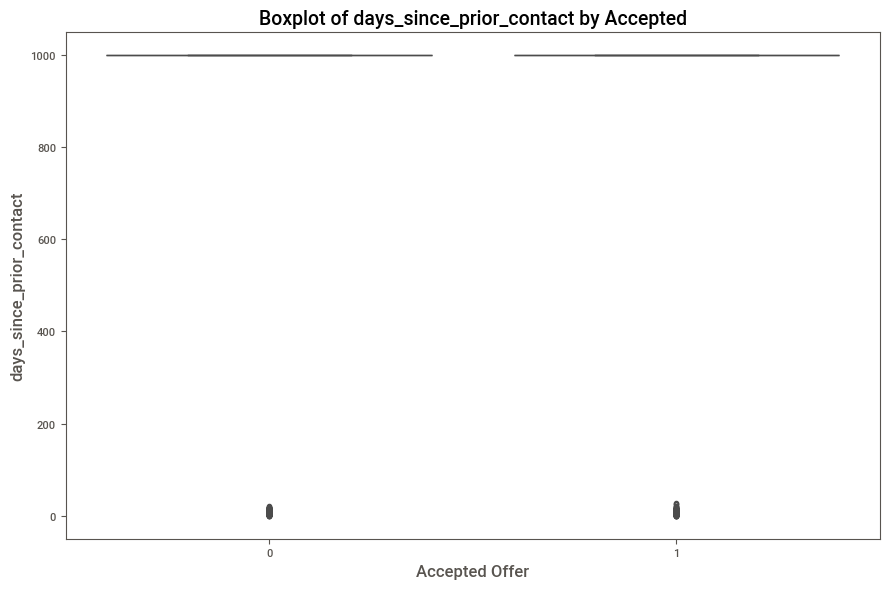

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



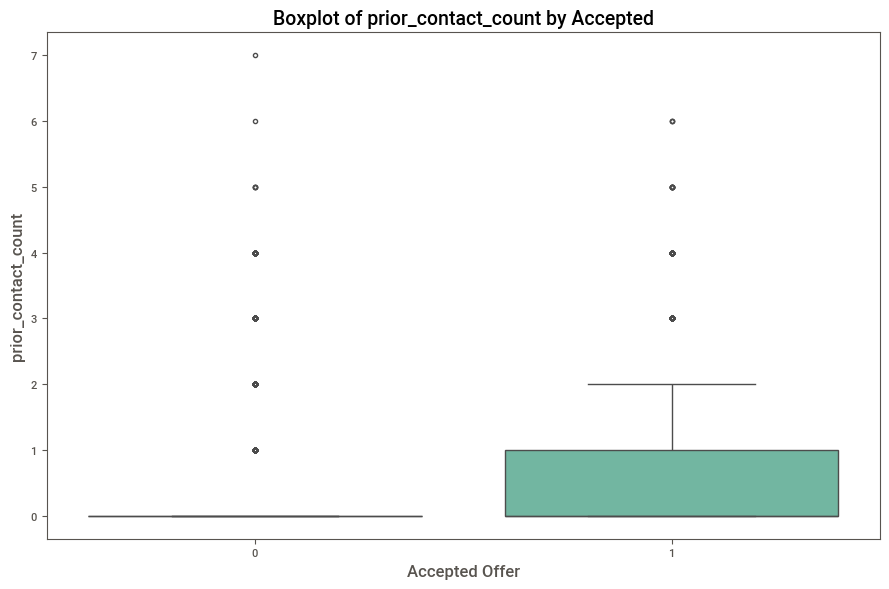

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



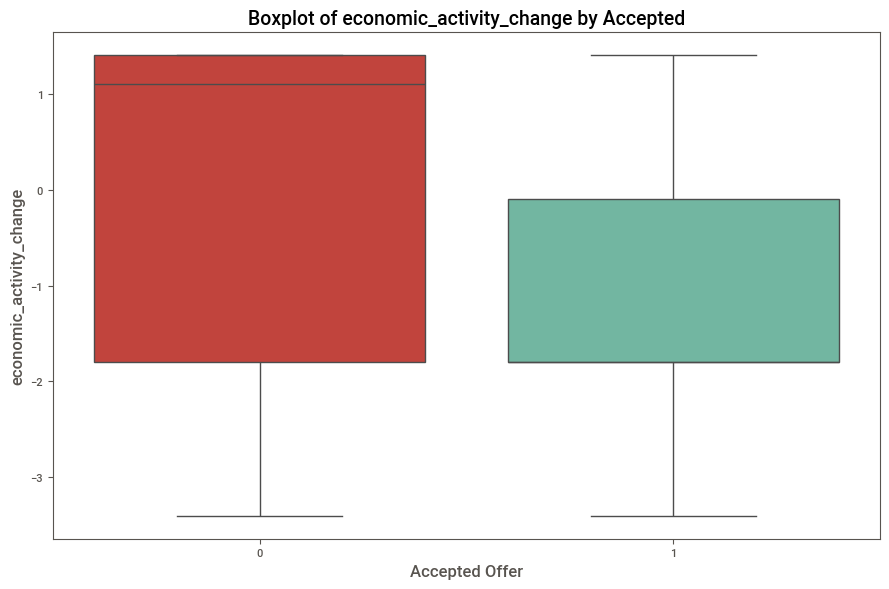

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



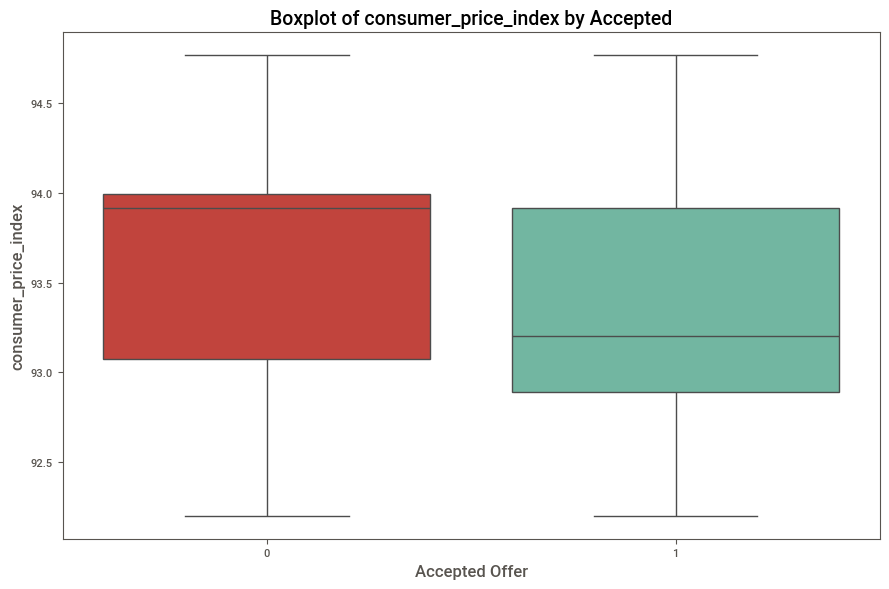

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



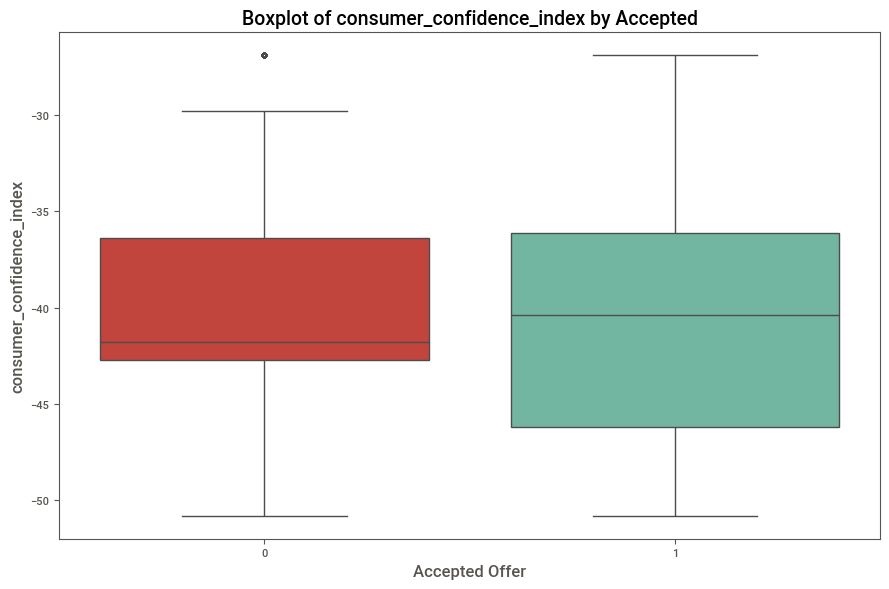

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



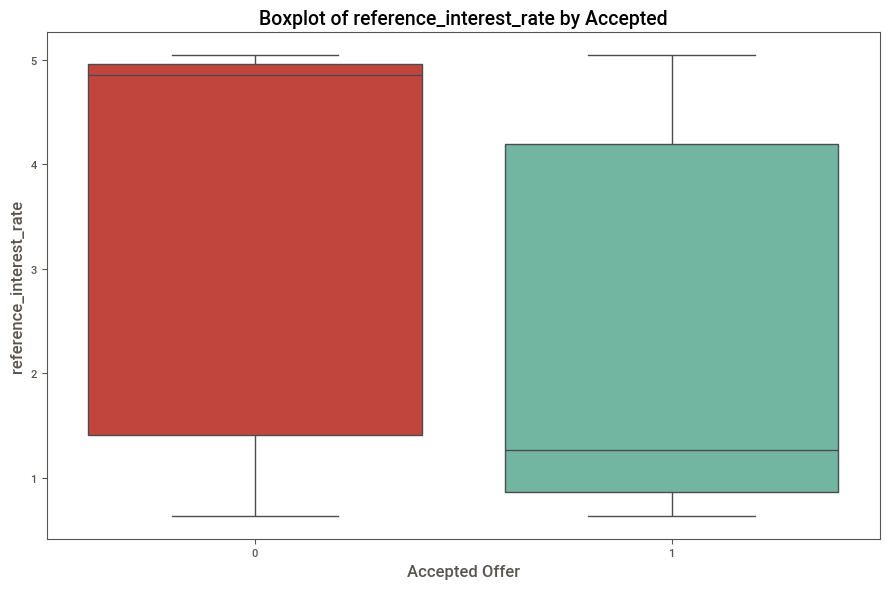

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



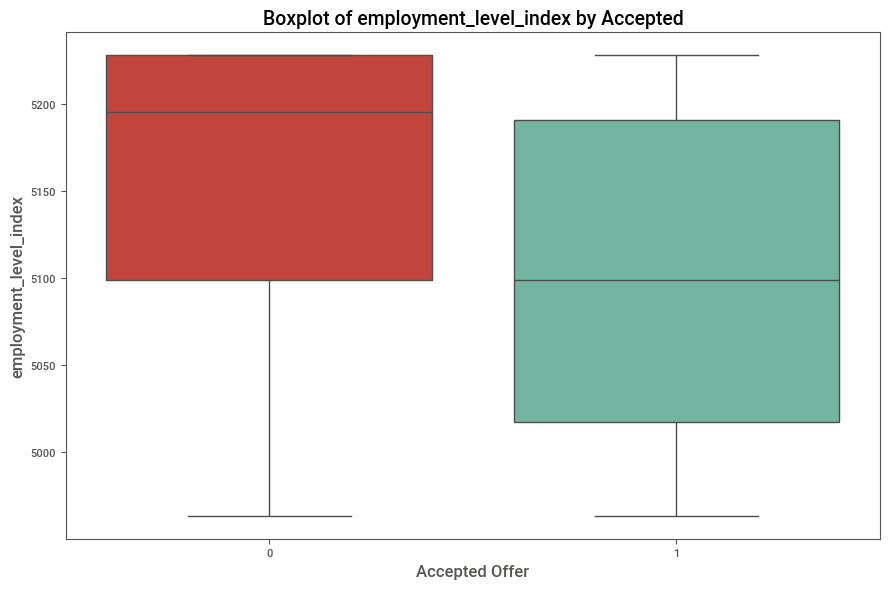

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



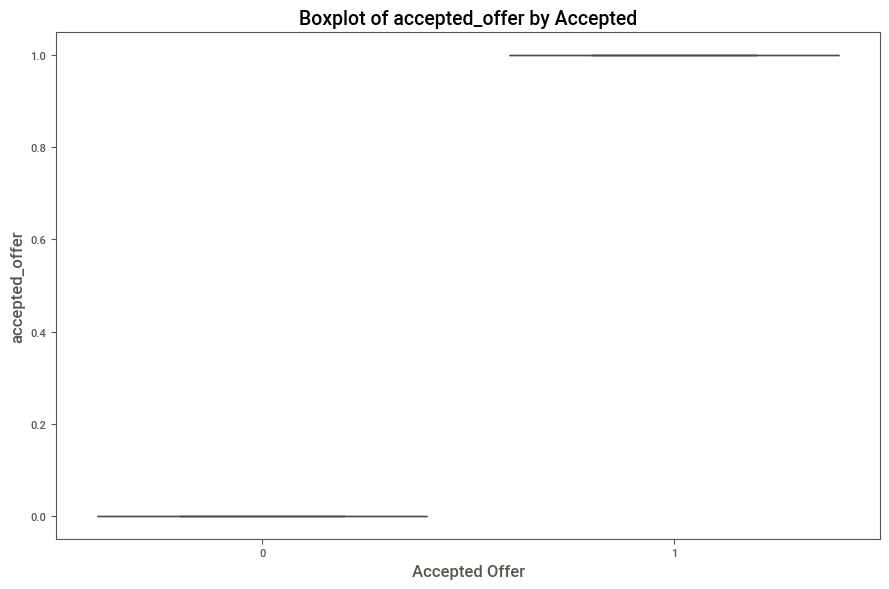

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



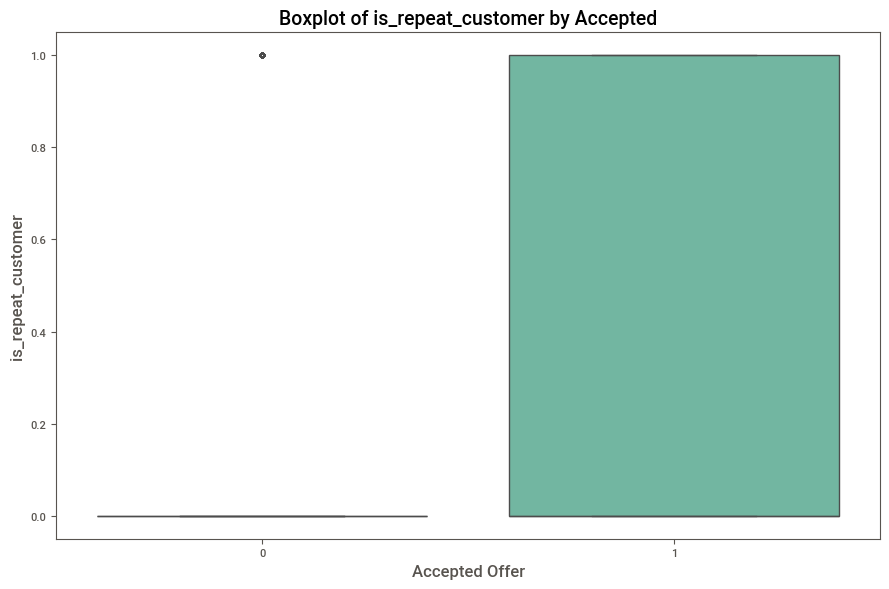

C:\Users\Dirks Wright\AppData\Local\Temp\ipykernel_17052\3260883441.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



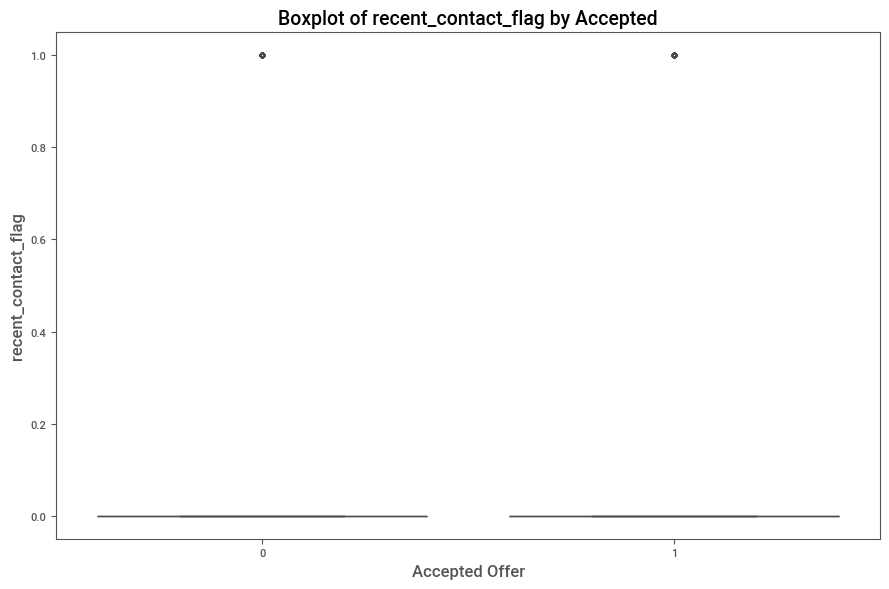

In [8]:
### boxplot of numeric features by target variable (accepted offer)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'id']  # Remove 'id' column

for feature in numeric_features:
    plt.figure(figsize=(9, 6))
    sns.boxplot(data=df, x='accepted_offer', y=feature, palette={'1': '#66c2a5', '0': '#d73027'})
    plt.title(f'Boxplot of {feature} by Accepted', fontsize=14, fontweight='bold')
    plt.xlabel('Accepted Offer', fontsize=12)
    plt.ylabel(feature, fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

#### Numeric Takeaways

Based on the graphs of the number variables, customers that are repeats seem to be more likely to accept the offer. Additionally, while there is strong overlap between accept the offer and don't accept the offer, more accepted offers occur at lower interest rates and CPI

### Categorical Visualizations

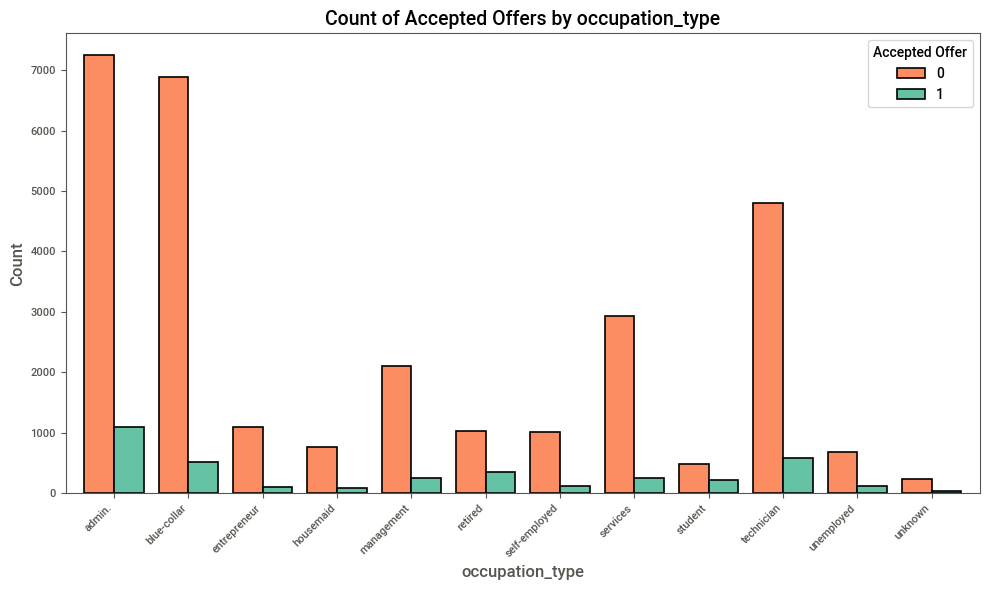

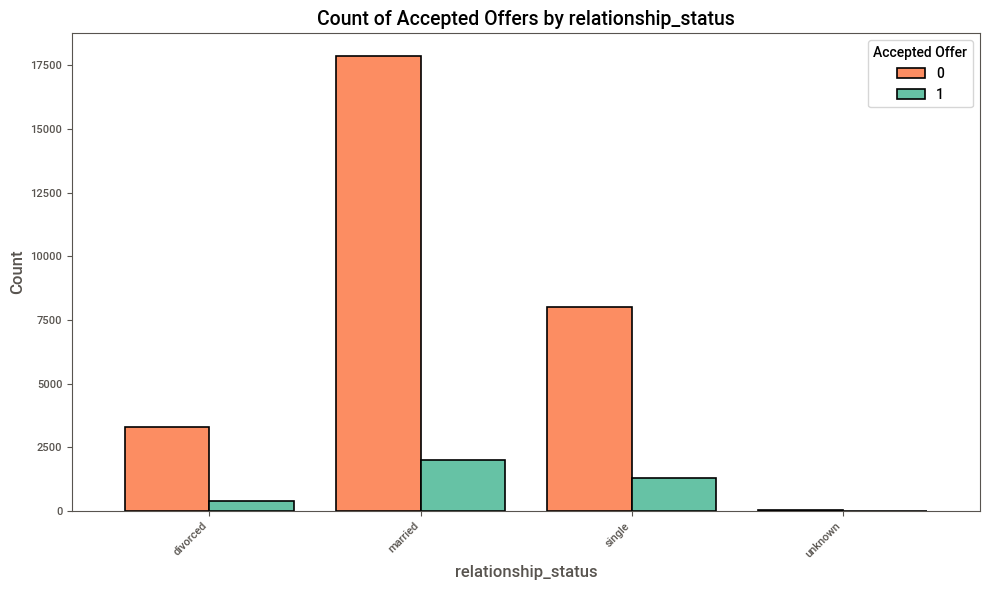

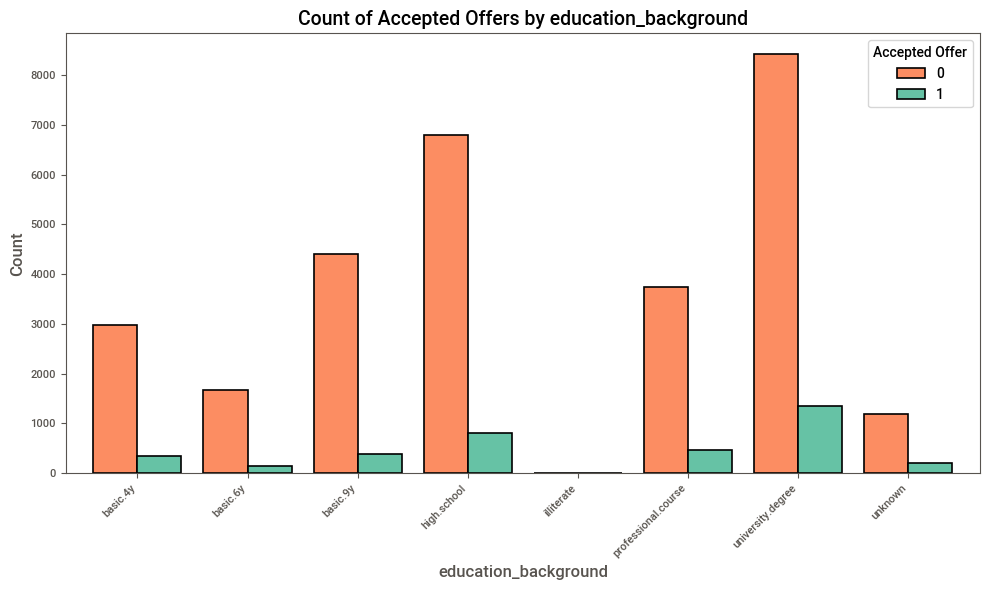

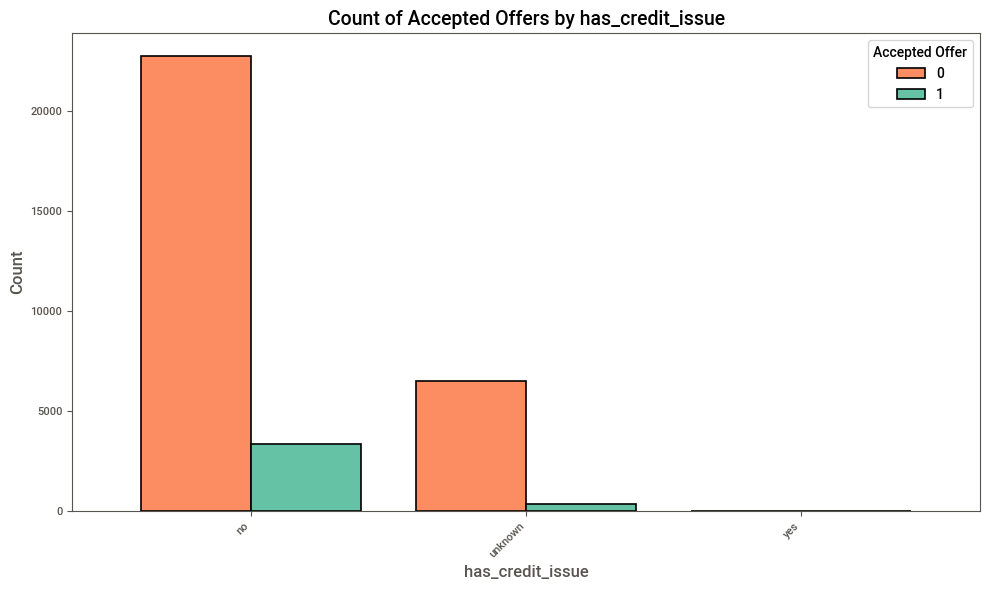

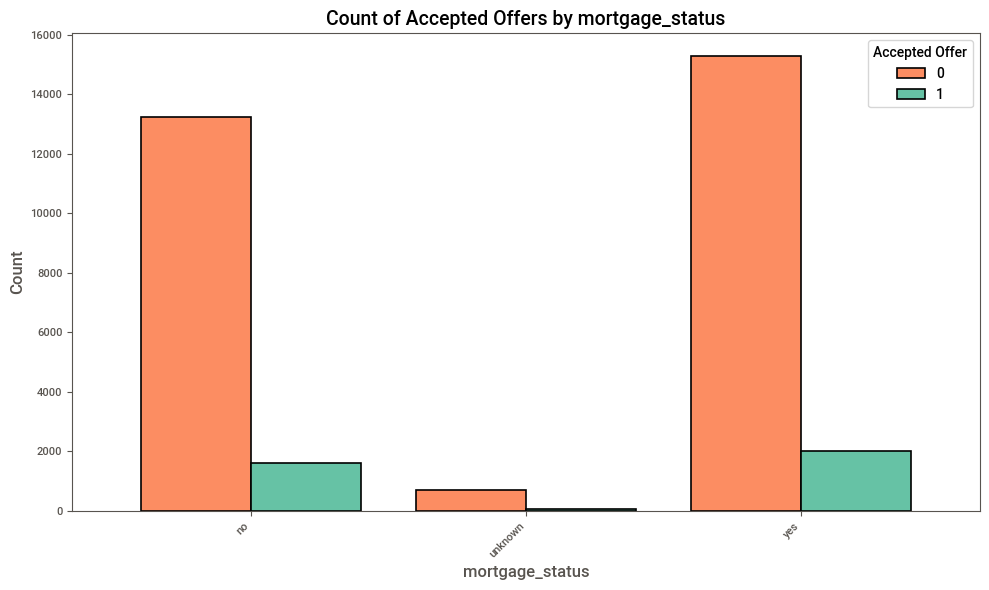

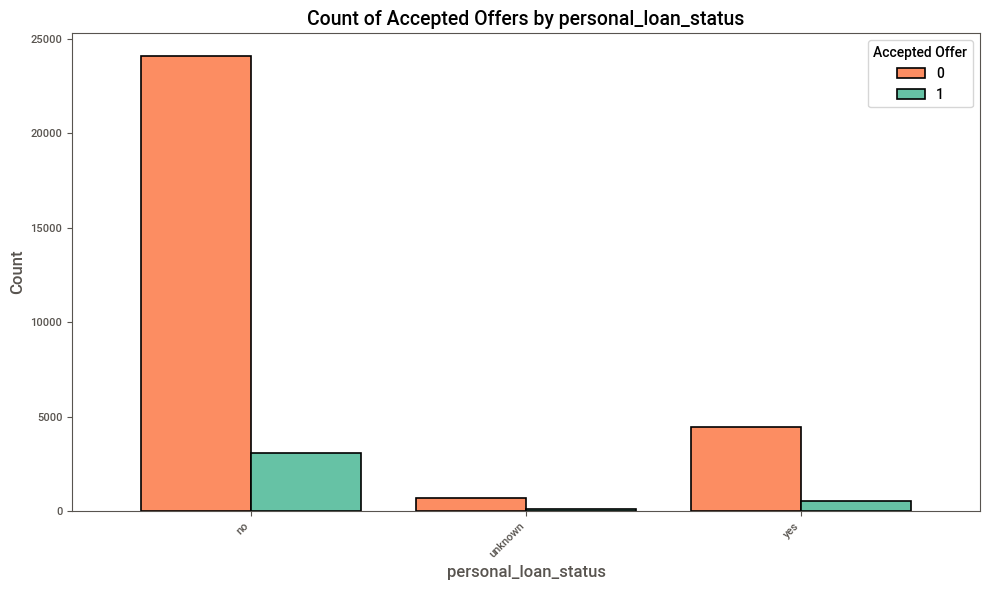

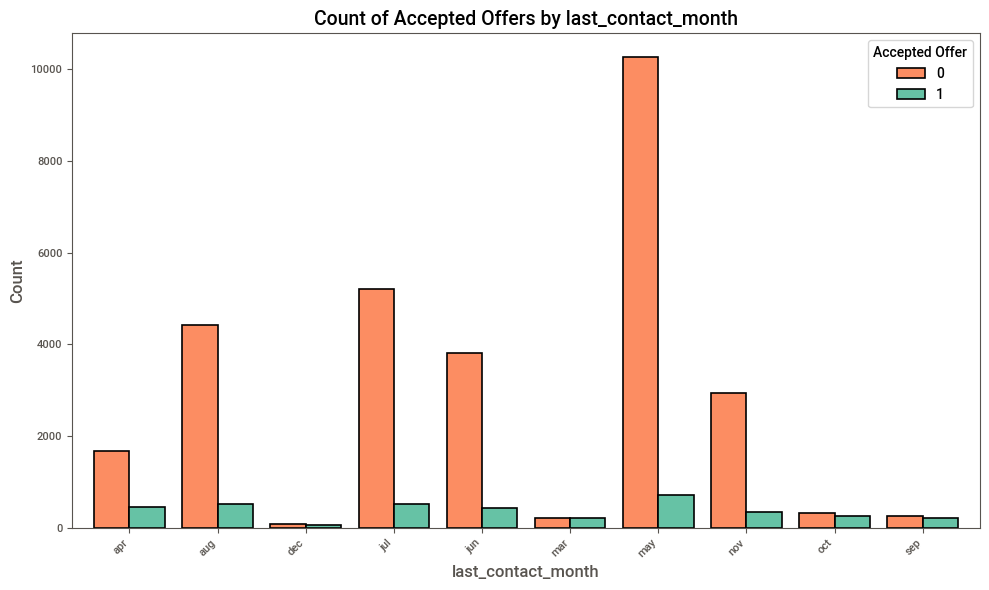

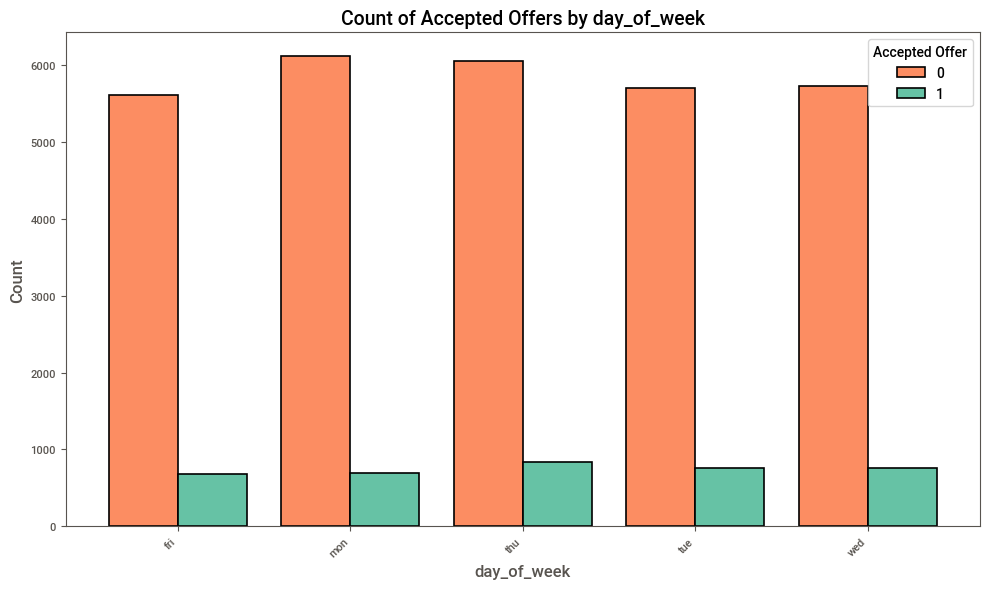

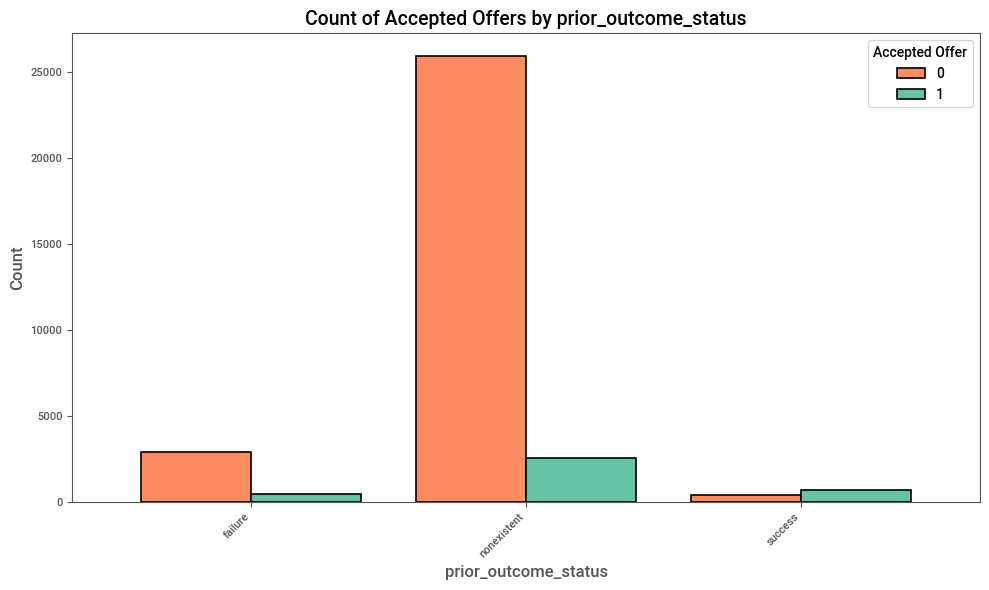

In [9]:
### barplot of each numeric feature by target variable
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features if col != 'accepted_offer']

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    crosstab = pd.crosstab(df[feature], df['accepted_offer'])
    crosstab = crosstab.reindex(columns=[0, 1])
    crosstab.plot(kind='bar', ax=plt.gca(), 
                  color=['#fc8d62','#66c2a5'], 
                  edgecolor='black', linewidth=1.2, width=0.8)
    plt.title(f'Count of Accepted Offers by {feature}', fontsize=14, fontweight='bold')
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.legend(title='Accepted Offer', loc='upper right')
    plt.xticks(rotation=45, ha='right')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

#### Categorical Takeaways

The strongest categorical signal appears in `prior_outcome_status`. Customers with a prior successful campaign outcome have a much higher acceptance rate than customers with a prior failure or no previous outcome, suggesting past response behavior is highly predictive.

`last_contact_month` also shows a clear pattern. Some months, especially March, December, September, and October, have much higher acceptance rates than high-volume months like May. This suggests campaign timing may be important, although smaller month counts should be interpreted carefully.

`occupation_type` and `relationship status` show meaningful separation as well. Students and retired customers accept offers at higher rates, while blue-collar and services customers show lower acceptance rates. By comparison, `mortgage_status`, `personal_loan_status`, and `day_of_week` show smaller differences, so they may provide incremental signal but are less likely to drive predictions on their own.


## Data Preparation

The target is `accepted_offer`. I use a stratified train/validation split to preserve the acceptance-rate imbalance in both sets.

In [10]:
### Preprocessing
### clarify target variable from predictors
target = "accepted_offer"

X = df.drop(columns=[target, 'id'])
y = df[target]

### train validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=222,
    stratify=y
)

In [11]:
### define numerical and catergorical variables
categorical_cols = X_train.select_dtypes(include=["object", 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

Categorical and numeric predictors are separated so the categorical variables can be encoded while preserving the numeric columns for interaction-feature generation.

## Feature Engineering

This section transforms the raw predictors into a numeric modeling matrix, creates interaction features, and then reduces the expanded feature space. All transformations are fit on the training data and applied to validation data to avoid leakage.

In [12]:
### import feature engineering and selection libraries
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import permutation_importance
import shap

In [13]:
X_train_og = X_train.copy()

In [14]:
### generate new features

### collapse rare categories
rare_encoder = RareLabelEncoder(tol=0.01, variables=categorical_cols)

X_train = rare_encoder.fit_transform(X_train)
X_val = rare_encoder.transform(X_val)

### frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=categorical_cols, encoding_method='frequency')

X_train = freq_encoder.fit_transform(X_train)
X_val = freq_encoder.transform(X_val)

''' choose either discretization or polynomial features'''
### interaction features through degree 3
poly = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

poly_feature_names = poly.get_feature_names_out(X_train.columns)

X_train = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_val = pd.DataFrame(X_val_poly, columns=poly_feature_names, index=X_val.index)

'''
### exclude problematic variables
disc_vars = [col for col in numeric_cols if col not in []]

### discretize numeric variables
disc = EqualFrequencyDiscretiser(q=5, variables=disc_vars)

X_train = disc.fit_transform(X_train)
X_val = disc.transform(X_val)
'''

### drop constant features based on training data only
const_drop = DropConstantFeatures()

X_train = const_drop.fit_transform(X_train)
X_val = const_drop.transform(X_val)

### print shapes
print(f"Original Shape: {X_train_og.shape}")
print(f"Transformed Train Shape: {X_train.shape}")
print(f"Transformed Validation Shape: {X_val.shape}")

c:\Users\Dirks Wright\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable relationship_status is less than that indicated in n_categories. Thus, all categories will be considered frequent
c:\Users\Dirks Wright\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable education_background is less than that indicated in n_categories. Thus, all categories will be considered frequent
c:\Users\Dirks Wright\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable has_credit_issue is less than that indicated in n_categories. Thus, all categories will be considered frequent
c:\Users\Dirks Wright\anaconda3\Lib\site-packages\feature_engine\encoding\rare_label.py:216: UserWarning: The number of unique categories for variable mortgage_status is less than that indicated in n_categor

Original Shape: (26360, 21)
Transformed Train Shape: (26360, 1561)
Transformed Validation Shape: (6590, 1561)


Rare-category handling reduces noise from very small groups, frequency encoding converts categorical variables into numeric predictors, and interaction features allow models to capture combined effects.

In [15]:
for col in X_train.columns:
    print(col)

customer_age
occupation_type
relationship_status
education_background
has_credit_issue
mortgage_status
personal_loan_status
last_contact_month
day_of_week
contact_time_minutes
contact_attempt_count
days_since_prior_contact
prior_contact_count
prior_outcome_status
economic_activity_change
consumer_price_index
consumer_confidence_index
reference_interest_rate
employment_level_index
is_repeat_customer
recent_contact_flag
customer_age occupation_type
customer_age relationship_status
customer_age education_background
customer_age has_credit_issue
customer_age mortgage_status
customer_age personal_loan_status
customer_age last_contact_month
customer_age day_of_week
customer_age contact_time_minutes
customer_age contact_attempt_count
customer_age days_since_prior_contact
customer_age prior_contact_count
customer_age prior_outcome_status
customer_age economic_activity_change
customer_age consumer_price_index
customer_age consumer_confidence_index
customer_age reference_interest_rate
customer_a

### Early Models and Feature Selection

I first train several baseline models on the full engineered feature set. These early models provide a benchmark before reducing the feature space and help show whether feature selection improves or simplifies the workflow.

In [16]:
### baseline models for feature selection
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state=222)

### baseline random forest
rf_baseline = RandomForestClassifier(class_weight = 'balanced', random_state = 222)
rf_cv = cross_val_score(rf_baseline, X_train, y_train, cv = skf, scoring = 'balanced_accuracy')
print(f"Random Forest CV Balanced Accuracy Scores: {rf_cv}")
rf_baseline.fit(X_train, y_train)
rf_preds = rf_baseline.predict(X_val)
print('Random Forest Validation Balanced Accuracy', balanced_accuracy_score(y_val, rf_preds))

### baseline logistic regression
lg_baseline = LogisticRegression(max_iter = 1000, random_state = 222)
lg_cv = cross_val_score(lg_baseline, X_train, y_train, cv = skf, scoring = 'balanced_accuracy')
print("Logistic Regression Balanced Accuracy Score:", lg_cv)
lg_baseline.fit(X_train, y_train)
lg_preds = lg_baseline.predict(X_val)
print ('Logistic Regression Validation Balanced Accuracy:', balanced_accuracy_score(y_val, lg_preds))

### baseline XGBoost
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos


xgb_baseline = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=222)
xgb_cv = cross_val_score(xgb_baseline, X_train, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost Balanced Accuracy Scores:", xgb_cv)    
xgb_baseline.fit(X_train, y_train)
xgb_preds = xgb_baseline.predict(X_val)
print("XGBoost Validation Balanced Accuracy:", balanced_accuracy_score(y_val, xgb_preds)) 



Random Forest CV Balanced Accuracy Scores: [0.69801262 0.70286267 0.70011034 0.70764514 0.70854764]
Random Forest Validation Balanced Accuracy 0.6932435471504063


c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
c:\Users\Dirks Wright\anaconda3\

Logistic Regression Balanced Accuracy Score: [0.67528535 0.69308231 0.67226562 0.69875198 0.68260413]


c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Logistic Regression Validation Balanced Accuracy: 0.664135776338811
XGBoost Balanced Accuracy Scores: [0.82398267 0.82050878 0.82438357 0.84429436 0.83032936]
XGBoost Validation Balanced Accuracy: 0.8329745891245146


In [17]:
### feature importances from baseline models
rf_importances = pd.Series(rf_baseline.feature_importances_, index=X_train.columns).sort_values(ascending=False)
lg_importances = pd.Series(lg_baseline.coef_[0], index = X_train.columns).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_baseline.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))
print('\nTop 10 Logistic Regression Feature Importances:')
print(lg_importances.head(10))
print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))

Top 10 Random Forest Feature Importances:
contact_time_minutes consumer_confidence_index                             0.019512
contact_time_minutes economic_activity_change consumer_confidence_index    0.012982
last_contact_month consumer_confidence_index reference_interest_rate       0.012676
contact_time_minutes consumer_price_index                                  0.012662
mortgage_status contact_time_minutes economic_activity_change              0.012649
customer_age contact_time_minutes                                          0.012244
contact_time_minutes consumer_price_index consumer_confidence_index        0.011926
day_of_week contact_time_minutes                                           0.011684
contact_time_minutes economic_activity_change employment_level_index       0.011599
contact_time_minutes consumer_confidence_index employment_level_index      0.011307
dtype: float64

Top 10 Logistic Regression Feature Importances:
contact_time_minutes economic_activity_change employme

The baseline models provide an initial performance reference before the selected-feature workflow. Feature-importance output is used for inspection, while the final feature selection step below uses a training-only LightGBM selector.

#### Rest of Baseline Models
`LightGBM`,
`HGBoost`,
`Catboost`

In [18]:
### baseline models for feature selection: HGBoost, CatBoost, LightGBM

from lightgbm import LGBMClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=222)

### baseline HistGradientBoosting
hgb_baseline = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=222
)

hgb_cv = cross_val_score(hgb_baseline, X_train, y_train, cv=skf, scoring='balanced_accuracy')
print(f"HistGradientBoosting CV Balanced Accuracy Scores: {hgb_cv}")

hgb_baseline.fit(X_train, y_train)
hgb_preds = hgb_baseline.predict(X_val)

print("HistGradientBoosting Validation Balanced Accuracy:", balanced_accuracy_score(y_val, hgb_preds))


### baseline CatBoost
cat_baseline = CatBoostClassifier(
    auto_class_weights='Balanced',
    loss_function='Logloss',
    eval_metric='BalancedAccuracy',
    random_seed=222,
    verbose=0
)

cat_cv = cross_val_score(cat_baseline, X_train, y_train, cv=skf, scoring='balanced_accuracy')
print(f"CatBoost CV Balanced Accuracy Scores: {cat_cv}")

cat_baseline.fit(X_train, y_train)
cat_preds = cat_baseline.predict(X_val)

print("CatBoost Validation Balanced Accuracy:", balanced_accuracy_score(y_val, cat_preds))


### baseline LightGBM
lgbm_baseline = LGBMClassifier(
    class_weight='balanced',
    objective='binary',
    random_state=222,
    verbose=-1
)

lgbm_cv = cross_val_score(lgbm_baseline, X_train, y_train, cv=skf, scoring='balanced_accuracy')
print(f"LightGBM CV Balanced Accuracy Scores: {lgbm_cv}")

lgbm_baseline.fit(X_train, y_train)
lgbm_preds = lgbm_baseline.predict(X_val)

print("LightGBM Validation Balanced Accuracy:", balanced_accuracy_score(y_val, lgbm_preds))


HistGradientBoosting CV Balanced Accuracy Scores: [0.88150351 0.88583246 0.87948604 0.89802376 0.87996399]
HistGradientBoosting Validation Balanced Accuracy: 0.8842297795213567
CatBoost CV Balanced Accuracy Scores: [0.86919753 0.87257785 0.86816865 0.87823355 0.87510345]
CatBoost Validation Balanced Accuracy: 0.8726150760958962
LightGBM CV Balanced Accuracy Scores: [0.87817609 0.87533019 0.87395402 0.88830267 0.87334569]
LightGBM Validation Balanced Accuracy: 0.8763850553400635


In [19]:
### feature importances from CatBoost and LightGBM baseline models

cat_importances = pd.Series(
    cat_baseline.get_feature_importance(),
    index=X_train.columns
).sort_values(ascending=False)

lgbm_importances = pd.Series(
    lgbm_baseline.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 10 CatBoost Feature Importances:")
print(cat_importances.head(10))

print("\nTop 10 LightGBM Feature Importances:")
print(lgbm_importances.head(10))


Top 10 CatBoost Feature Importances:
last_contact_month days_since_prior_contact reference_interest_rate      2.390316
contact_time_minutes consumer_price_index consumer_confidence_index      2.077300
last_contact_month economic_activity_change reference_interest_rate      1.900825
contact_time_minutes employment_level_index                              1.887145
last_contact_month day_of_week reference_interest_rate                   1.820249
day_of_week contact_time_minutes consumer_price_index                    1.817919
contact_time_minutes prior_outcome_status                                1.587173
day_of_week contact_time_minutes employment_level_index                  1.544780
has_credit_issue contact_time_minutes economic_activity_change           1.443857
contact_time_minutes consumer_confidence_index employment_level_index    1.398553
dtype: float64

Top 10 LightGBM Feature Importances:
reference_interest_rate                                                26
contact_time_mi

#### Feature Selection

The final feature set is selected using LightGBM feature importances computed on the training data only. I compare several top-k feature counts with cross-validation and keep one shared selected feature set for all downstream models and ensembles.

In [20]:
### training-only feature selection with LightGBM
selector_model = LGBMClassifier(
    class_weight='balanced',
    objective='binary',
    random_state=222,
    n_jobs=-1,
    verbose=-1
)

selector_model.fit(X_train, y_train)

feature_rankings = pd.DataFrame({
    "feature": X_train.columns,
    "importance": selector_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Top 25 LightGBM selector features:")
display(feature_rankings.head(25))

Top 25 LightGBM selector features:


,feature,importance
17,reference_interest_rate,26
171,contact_time_minutes consumer_confidence_index,24
212,economic_activity_change reference_interest_rate,22
919,has_credit_issue last_contact_month reference_...,20
821,education_background contact_time_minutes cons...,18
303,customer_age mortgage_status day_of_week,18
1046,mortgage_status contact_time_minutes consumer_...,18
289,customer_age has_credit_issue contact_time_min...,18
304,customer_age mortgage_status contact_time_minutes,17
355,customer_age contact_time_minutes contact_atte...,17


In [21]:
### compare top-k feature counts using training cross-validation

k_values = [25, 50, 75, 100, 150, 200, 300, 500]
k_values = [k for k in k_values if k <= X_train.shape[1]]

k_results = []

for k in k_values:
    top_k_features = feature_rankings.head(k)["feature"].tolist()
    
    model = LGBMClassifier(
        class_weight='balanced',
        objective='binary',
        random_state=222,
        n_jobs=-1,
        verbose=-1
    )
    
    scores = cross_val_score(
        model,
        X_train[top_k_features],
        y_train,
        cv=skf,
        scoring='balanced_accuracy'
    )
    
    k_results.append({
        "k_features": k,
        "cv_balanced_accuracy_mean": scores.mean(),
        "cv_balanced_accuracy_std": scores.std()
    })

k_results_df = pd.DataFrame(k_results).sort_values(
    by="cv_balanced_accuracy_mean",
    ascending=False
)

display(k_results_df)

,k_features,cv_balanced_accuracy_mean,cv_balanced_accuracy_std
1,50,0.884455,0.004118
2,75,0.882482,0.007602
3,100,0.880575,0.007032
0,25,0.879968,0.004065
4,150,0.879755,0.005493
5,200,0.877352,0.005733
7,500,0.875694,0.005379
6,300,0.873585,0.006759


In [22]:
### create one shared selected feature dataset for all models

best_k = int(k_results_df.iloc[0]["k_features"])
selected_features = feature_rankings.head(best_k)["feature"].tolist()

X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]

print("Best number of selected features:", best_k)
print("Selected train shape:", X_train_selected.shape)
print("Selected validation shape:", X_val_selected.shape)

Best number of selected features: 50
Selected train shape: (26360, 50)
Selected validation shape: (6590, 50)


The selected feature count is chosen from cross-validated training performance, not validation performance.

In [23]:
### selected features
print("Selected features:")
for feature in selected_features:
    print(feature)

Selected features:
reference_interest_rate
contact_time_minutes consumer_confidence_index
economic_activity_change reference_interest_rate
has_credit_issue last_contact_month reference_interest_rate
education_background contact_time_minutes consumer_confidence_index
customer_age mortgage_status day_of_week
mortgage_status contact_time_minutes consumer_confidence_index
customer_age has_credit_issue contact_time_minutes
customer_age mortgage_status contact_time_minutes
customer_age contact_time_minutes contact_attempt_count
has_credit_issue contact_time_minutes
customer_age relationship_status contact_time_minutes
customer_age relationship_status contact_attempt_count
last_contact_month reference_interest_rate
customer_age contact_time_minutes consumer_confidence_index
customer_age mortgage_status consumer_confidence_index
occupation_type contact_time_minutes contact_attempt_count
last_contact_month economic_activity_change reference_interest_rate
last_contact_month day_of_week reference

#### Reduced Dataset

Using one shared reduced dataset keeps the model comparison fair and makes ensembling straightforward. Each model below uses the same selected predictors, so performance differences come from the model family and tuning rather than different feature subsets.

In [24]:
### reduced dataset shape

print("All models will use:")
print("X_train_selected:", X_train_selected.shape)
print("X_val_selected:", X_val_selected.shape)

All models will use:
X_train_selected: (26360, 50)
X_val_selected: (6590, 50)


In [25]:
### Random Forest on selected features

rf_baseline_selected = RandomForestClassifier(
    class_weight='balanced',
    random_state=222
)

rf_cv_scores_selected = cross_val_score(
    rf_baseline_selected,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)

print("Random Forest CV Balanced Accuracy Scores (Selected Features):", rf_cv_scores_selected)

rf_baseline_selected.fit(X_train_selected, y_train)
rf_preds_selected = rf_baseline_selected.predict(X_val_selected)

print("Random Forest Selected Features Validation Balanced Accuracy:", balanced_accuracy_score(y_val, rf_preds_selected))

Random Forest CV Balanced Accuracy Scores (Selected Features): [0.71420634 0.70661726 0.69217398 0.70591973 0.70576808]
Random Forest Selected Features Validation Balanced Accuracy: 0.6819521393561848


In [26]:
### Logistic Regression on selected features

lg_baseline_selected = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=222
)

lg_cv_scores_selected = cross_val_score(
    lg_baseline_selected,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)

print("Logistic Regression CV Balanced Accuracy Scores (Selected Features):", lg_cv_scores_selected)

lg_baseline_selected.fit(X_train_selected, y_train)
lg_preds_selected = lg_baseline_selected.predict(X_val_selected)

print("Logistic Regression Selected Features Validation Balanced Accuracy:", balanced_accuracy_score(y_val, lg_preds_selected))

c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
c:\Users\Dirks Wright\anaconda3\

Logistic Regression CV Balanced Accuracy Scores (Selected Features): [0.84872992 0.85340616 0.858764   0.86788863 0.86200628]
Logistic Regression Selected Features Validation Balanced Accuracy: 0.8677552832767192


c:\Users\Dirks Wright\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


In [27]:
### XGBoost on selected features

xgb_baseline_selected = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=222
)

xgb_cv_scores_selected = cross_val_score(
    xgb_baseline_selected,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)

print("XGBoost CV Balanced Accuracy Scores (Selected Features):", xgb_cv_scores_selected)

xgb_baseline_selected.fit(X_train_selected, y_train)
xgb_preds_selected = xgb_baseline_selected.predict(X_val_selected)

print("XGBoost Selected Features Validation Balanced Accuracy:", balanced_accuracy_score(y_val, xgb_preds_selected))

XGBoost CV Balanced Accuracy Scores (Selected Features): [0.84855394 0.81626008 0.83090381 0.83269872 0.83656477]
XGBoost Selected Features Validation Balanced Accuracy: 0.8390273186534789


In [28]:
### HistGradientBoosting on selected features

hgb_baseline_selected = HistGradientBoostingClassifier(
    class_weight='balanced',
    random_state=222
)

hgb_cv_scores_selected = cross_val_score(
    hgb_baseline_selected,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)

print("HistGradientBoosting CV Balanced Accuracy Scores (Selected Features):", hgb_cv_scores_selected)

hgb_baseline_selected.fit(X_train_selected, y_train)
hgb_preds_selected = hgb_baseline_selected.predict(X_val_selected)

print("HistGradientBoosting Selected Features Validation Balanced Accuracy:", balanced_accuracy_score(y_val, hgb_preds_selected))

HistGradientBoosting CV Balanced Accuracy Scores (Selected Features): [0.88400213 0.88469705 0.88377505 0.88934694 0.89078397]
HistGradientBoosting Selected Features Validation Balanced Accuracy: 0.886832257561078


In [29]:
### CatBoost on selected features

cat_baseline_selected = CatBoostClassifier(
    auto_class_weights='Balanced',
    loss_function='Logloss',
    eval_metric='BalancedAccuracy',
    random_seed=222,
    verbose=0
)

cat_cv_scores_selected = cross_val_score(
    cat_baseline_selected,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)

print("CatBoost CV Balanced Accuracy Scores (Selected Features):", cat_cv_scores_selected)

cat_baseline_selected.fit(X_train_selected, y_train)
cat_preds_selected = cat_baseline_selected.predict(X_val_selected)

print("CatBoost Selected Features Validation Balanced Accuracy:", balanced_accuracy_score(y_val, cat_preds_selected))

CatBoost CV Balanced Accuracy Scores (Selected Features): [0.88128938 0.86914427 0.87276499 0.87724157 0.88150542]
CatBoost Selected Features Validation Balanced Accuracy: 0.8790024954417502


In [30]:
### LightGBM on selected features

lgbm_baseline_selected = LGBMClassifier(
    class_weight='balanced',
    objective='binary',
    random_state=222,
    n_jobs=-1,
    verbose=-1
)

lgbm_cv_scores_selected = cross_val_score(
    lgbm_baseline_selected,
    X_train_selected,
    y_train,
    cv=skf,
    scoring='balanced_accuracy'
)

print("LightGBM CV Balanced Accuracy Scores (Selected Features):", lgbm_cv_scores_selected)

lgbm_baseline_selected.fit(X_train_selected, y_train)
lgbm_preds_selected = lgbm_baseline_selected.predict(X_val_selected)

print("LightGBM Selected Features Validation Balanced Accuracy:", balanced_accuracy_score(y_val, lgbm_preds_selected))

LightGBM CV Balanced Accuracy Scores (Selected Features): [0.88193068 0.87818976 0.8844293  0.88847175 0.88925243]
LightGBM Selected Features Validation Balanced Accuracy: 0.8819470292365597


In [31]:
### compare balanced accuracy before and after feature selection

before_after_results = pd.DataFrame({
    "model": [
        "Random Forest",
        "Logistic Regression",
        "XGBoost",
        "HistGradientBoosting",
        "CatBoost",
        "LightGBM"
    ],
    "before_feature_selection": [
        balanced_accuracy_score(y_val, rf_preds),
        balanced_accuracy_score(y_val, lg_preds),
        balanced_accuracy_score(y_val, xgb_preds),
        balanced_accuracy_score(y_val, hgb_preds),
        balanced_accuracy_score(y_val, cat_preds),
        balanced_accuracy_score(y_val, lgbm_preds)
    ],
    "after_feature_selection": [
        balanced_accuracy_score(y_val, rf_preds_selected),
        balanced_accuracy_score(y_val, lg_preds_selected),
        balanced_accuracy_score(y_val, xgb_preds_selected),
        balanced_accuracy_score(y_val, hgb_preds_selected),
        balanced_accuracy_score(y_val, cat_preds_selected),
        balanced_accuracy_score(y_val, lgbm_preds_selected)
    ]
})

before_after_results["difference"] = (
    before_after_results["after_feature_selection"] -
    before_after_results["before_feature_selection"]
)

before_after_results = before_after_results.sort_values(
    by="after_feature_selection",
    ascending=False
)

before_after_results


,model,before_feature_selection,after_feature_selection,difference
3,HistGradientBoosting,0.884230,0.886832,0.002602
5,LightGBM,0.876385,0.881947,0.005562
4,CatBoost,0.872615,0.879002,0.006387
1,Logistic Regression,0.664136,0.867755,0.203620
2,XGBoost,0.832975,0.839027,0.006053
0,Random Forest,0.693244,0.681952,-0.011291


Feature selection generally improved validation balanced accuracy while reducing the feature space. The largest gain came from Logistic Regression, which improved substantially after selection, suggesting the reduced feature set helped remove noisy or highly correlated interaction features. Tree-based boosting models also improved slightly, including HistGradientBoosting, LightGBM, CatBoost, and XGBoost. Random Forest was the only model that performed slightly worse after feature selection, so the reduced feature set is useful overall but not universally better for every model.


## Modeling and Evaluation

The tuned models are optimized with Optuna using stratified cross-validation on the training data. I evaluate all tuned models on the held-out validation set using balanced accuracy because the positive class is much smaller than the negative class.

In [32]:
### optuna for cross validation
import optuna

In [33]:
### tuning settings

n_trials = 15
tuning_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=222)

### helper function for Optuna tuning

def run_optuna_study(objective_func, model_name, n_trials=15):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_func, n_trials=n_trials)
    
    print(f"Best {model_name} CV Balanced Accuracy:", study.best_value)
    print(f"Best {model_name} Params:")
    print(study.best_params)
    
    return study



Optuna searches a compact hyperparameter space for each model. I use fewer folds and trials than an exhaustive search to keep runtime reasonable while still tuning beyond default settings.

In [34]:
### tune Random Forest

def rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
        "random_state": 222,
        "n_jobs": -1
    }
    
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train_selected, y_train, cv=tuning_cv, scoring="balanced_accuracy")
    return scores.mean()

rf_study = run_optuna_study(rf_objective, "Random Forest", n_trials)
rf_optuna = RandomForestClassifier(**rf_study.best_params, random_state=222, n_jobs=-1)
rf_optuna.fit(X_train_selected, y_train)
rf_optuna_preds = rf_optuna.predict(X_val_selected)

print("Random Forest Optuna Validation Balanced Accuracy:", balanced_accuracy_score(y_val, rf_optuna_preds))

[I 2026-05-08 14:18:31,850] A new study created in memory with name: no-name-78f5621d-3f55-4599-bc12-0518c4b7b38b
[I 2026-05-08 14:18:36,443] Trial 0 finished with value: 0.8615303205577449 and parameters: {'n_estimators': 144, 'max_depth': 24, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 0 with value: 0.8615303205577449.
[I 2026-05-08 14:18:45,639] Trial 1 finished with value: 0.8660435186918405 and parameters: {'n_estimators': 488, 'max_depth': 26, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8660435186918405.
[I 2026-05-08 14:18:58,203] Trial 2 finished with value: 0.8633296835218284 and parameters: {'n_estimators': 432, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}. Best is trial 1 with value: 0.8660435186918405.
[I 2026-05-08 14:20:21,903

Best Random Forest CV Balanced Accuracy: 0.8794061337396583
Best Random Forest Params:
{'n_estimators': 105, 'max_depth': 8, 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': 'balanced'}
Random Forest Optuna Validation Balanced Accuracy: 0.8871334553777219


In [36]:
### tune Logistic Regression

def lg_objective(trial):
    params = {
        "C": trial.suggest_float("C", 0.001, 10, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "penalty": "l2",
        "solver": "lbfgs",
        "max_iter": 1000,
        "random_state": 222
    }
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(**params))
    ])
    
    scores = cross_val_score(
        model,
        X_train_selected,
        y_train,
        cv=tuning_cv,
        scoring="balanced_accuracy",
        n_jobs=-1
    )
    
    return scores.mean()

lg_study = run_optuna_study(lg_objective, "Logistic Regression", n_trials=10)

lg_best_params = lg_study.best_params.copy()
lg_best_params["penalty"] = "l2"
lg_best_params["solver"] = "lbfgs"
lg_best_params["max_iter"] = 1000
lg_best_params["random_state"] = 222

lg_optuna = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(**lg_best_params))
])

lg_optuna.fit(X_train_selected, y_train)
lg_optuna_preds = lg_optuna.predict(X_val_selected)

print("Logistic Regression Optuna Validation Balanced Accuracy:", balanced_accuracy_score(y_val, lg_optuna_preds))


[I 2026-05-08 14:31:50,606] A new study created in memory with name: no-name-533107bc-db55-44ef-91b7-7356d525b27b
[I 2026-05-08 14:31:53,534] Trial 0 finished with value: 0.8617520113190613 and parameters: {'C': 0.0011207051680686868, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8617520113190613.
[I 2026-05-08 14:31:55,332] Trial 1 finished with value: 0.6235753362024229 and parameters: {'C': 0.005077094975330589, 'class_weight': None}. Best is trial 0 with value: 0.8617520113190613.
[I 2026-05-08 14:31:57,317] Trial 2 finished with value: 0.8616727453829354 and parameters: {'C': 0.3830260643095284, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8617520113190613.
[I 2026-05-08 14:31:59,205] Trial 3 finished with value: 0.8612694017620424 and parameters: {'C': 0.27250500805052463, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8617520113190613.
[I 2026-05-08 14:32:01,145] Trial 4 finished with value: 0.6267477247791482 and parameters: {'C': 0.006837

Best Logistic Regression CV Balanced Accuracy: 0.8621140001920672
Best Logistic Regression Params:
{'C': 0.004231491304655841, 'class_weight': 'balanced'}
Logistic Regression Optuna Validation Balanced Accuracy: 0.8747709941323396


In [37]:
### tune XGBoost

def xgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 1),
        "scale_pos_weight": spw,
        "eval_metric": "logloss",
        "random_state": 222
    }
    
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_selected, y_train, cv=tuning_cv, scoring="balanced_accuracy")
    return scores.mean()

xgb_study = run_optuna_study(xgb_objective, "XGBoost", n_trials)
xgb_optuna = XGBClassifier(**xgb_study.best_params, scale_pos_weight=spw, eval_metric="logloss", random_state=222)
xgb_optuna.fit(X_train_selected, y_train)
xgb_optuna_preds = xgb_optuna.predict(X_val_selected)

print("XGBoost Optuna Validation Balanced Accuracy:", balanced_accuracy_score(y_val, xgb_optuna_preds))

[I 2026-05-08 14:32:22,590] A new study created in memory with name: no-name-75b0128c-4f91-454d-8d83-7370b2ea6969
[I 2026-05-08 14:32:24,738] Trial 0 finished with value: 0.8864578462111726 and parameters: {'n_estimators': 144, 'max_depth': 6, 'learning_rate': 0.02651056310416314, 'subsample': 0.9641482794301516, 'colsample_bytree': 0.8216803277816004, 'min_child_weight': 8, 'gamma': 0.48083229916496373}. Best is trial 0 with value: 0.8864578462111726.
[I 2026-05-08 14:32:28,905] Trial 1 finished with value: 0.8233721042108252 and parameters: {'n_estimators': 689, 'max_depth': 7, 'learning_rate': 0.19963156404211063, 'subsample': 0.9984181953016396, 'colsample_bytree': 0.9192632592352262, 'min_child_weight': 4, 'gamma': 0.5252639687417393}. Best is trial 0 with value: 0.8864578462111726.
[I 2026-05-08 14:32:30,881] Trial 2 finished with value: 0.878806220062985 and parameters: {'n_estimators': 399, 'max_depth': 2, 'learning_rate': 0.014074472853697265, 'subsample': 0.6569467758254627, 

Best XGBoost CV Balanced Accuracy: 0.8864578462111726
Best XGBoost Params:
{'n_estimators': 144, 'max_depth': 6, 'learning_rate': 0.02651056310416314, 'subsample': 0.9641482794301516, 'colsample_bytree': 0.8216803277816004, 'min_child_weight': 8, 'gamma': 0.48083229916496373}
XGBoost Optuna Validation Balanced Accuracy: 0.8939781383557983


In [38]:
### tune HistGradientBoosting

def hgb_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_iter": trial.suggest_int("max_iter", 100, 500),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 10, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.001, 10, log=True),
        "class_weight": "balanced",
        "random_state": 222
    }
    
    model = HistGradientBoostingClassifier(**params)
    scores = cross_val_score(model, X_train_selected, y_train, cv=tuning_cv, scoring="balanced_accuracy")
    return scores.mean()

hgb_study = run_optuna_study(hgb_objective, "HistGradientBoosting", n_trials)
hgb_optuna = HistGradientBoostingClassifier(**hgb_study.best_params, class_weight="balanced", random_state=222)
hgb_optuna.fit(X_train_selected, y_train)
hgb_optuna_preds = hgb_optuna.predict(X_val_selected)

print("HistGradientBoosting Optuna Validation Balanced Accuracy:", balanced_accuracy_score(y_val, hgb_optuna_preds))

[I 2026-05-08 14:33:08,347] A new study created in memory with name: no-name-173fd770-a74b-4dea-a741-adcf1a9a59db
[I 2026-05-08 14:33:12,217] Trial 0 finished with value: 0.8876392313120326 and parameters: {'learning_rate': 0.013410262648140337, 'max_iter': 235, 'max_leaf_nodes': 30, 'min_samples_leaf': 33, 'l2_regularization': 6.423436511455957}. Best is trial 0 with value: 0.8876392313120326.
[I 2026-05-08 14:33:16,754] Trial 1 finished with value: 0.8844445285646602 and parameters: {'learning_rate': 0.016379050663781477, 'max_iter': 444, 'max_leaf_nodes': 38, 'min_samples_leaf': 55, 'l2_regularization': 0.9750995026248261}. Best is trial 0 with value: 0.8876392313120326.
[I 2026-05-08 14:33:17,713] Trial 2 finished with value: 0.8854017577835557 and parameters: {'learning_rate': 0.15419085868357088, 'max_iter': 269, 'max_leaf_nodes': 30, 'min_samples_leaf': 23, 'l2_regularization': 8.457065641489116}. Best is trial 0 with value: 0.8876392313120326.
[I 2026-05-08 14:33:20,198] Trial 

Best HistGradientBoosting CV Balanced Accuracy: 0.8887817694951189
Best HistGradientBoosting Params:
{'learning_rate': 0.05174663170592212, 'max_iter': 388, 'max_leaf_nodes': 19, 'min_samples_leaf': 20, 'l2_regularization': 0.9833324294955537}
HistGradientBoosting Optuna Validation Balanced Accuracy: 0.8908996365600056


In [39]:
### tune CatBoost

def cat_objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 700),
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "auto_class_weights": "Balanced",
        "loss_function": "Logloss",
        "eval_metric": "BalancedAccuracy",
        "random_seed": 222,
        "verbose": 0
    }
    
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train_selected, y_train, cv=tuning_cv, scoring="balanced_accuracy")
    return scores.mean()

cat_study = run_optuna_study(cat_objective, "CatBoost", n_trials)
cat_optuna = CatBoostClassifier(**cat_study.best_params, auto_class_weights="Balanced", loss_function="Logloss", eval_metric="BalancedAccuracy", random_seed=222, verbose=0)
cat_optuna.fit(X_train_selected, y_train)
cat_optuna_preds = cat_optuna.predict(X_val_selected)

print("CatBoost Optuna Validation Balanced Accuracy:", balanced_accuracy_score(y_val, cat_optuna_preds))

[I 2026-05-08 14:33:47,201] A new study created in memory with name: no-name-40afd48a-bfbc-4589-8aec-0fb2e5821af5
[I 2026-05-08 14:34:03,314] Trial 0 finished with value: 0.8871828459336918 and parameters: {'iterations': 559, 'depth': 3, 'learning_rate': 0.036013490024954, 'l2_leaf_reg': 3.3079459278157173}. Best is trial 0 with value: 0.8871828459336918.
[I 2026-05-08 14:34:24,721] Trial 1 finished with value: 0.8828469236797862 and parameters: {'iterations': 304, 'depth': 8, 'learning_rate': 0.023594174288523406, 'l2_leaf_reg': 4.751639941538739}. Best is trial 0 with value: 0.8871828459336918.
[I 2026-05-08 14:34:35,516] Trial 2 finished with value: 0.8767394345667299 and parameters: {'iterations': 374, 'depth': 3, 'learning_rate': 0.010603821231092216, 'l2_leaf_reg': 4.556462934613387}. Best is trial 0 with value: 0.8871828459336918.
[I 2026-05-08 14:34:43,136] Trial 3 finished with value: 0.8837298162450677 and parameters: {'iterations': 170, 'depth': 6, 'learning_rate': 0.0862812

Best CatBoost CV Balanced Accuracy: 0.8875275362526969
Best CatBoost Params:
{'iterations': 551, 'depth': 4, 'learning_rate': 0.03451196149522705, 'l2_leaf_reg': 9.994759346476526}
CatBoost Optuna Validation Balanced Accuracy: 0.8933237207839844


In [40]:
### tune LightGBM

def lgbm_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "num_leaves": trial.suggest_int("num_leaves", 10, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
        "class_weight": "balanced",
        "objective": "binary",
        "random_state": 222,
        "n_jobs": -1,
        "verbose": -1
    }
    
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_selected, y_train, cv=tuning_cv, scoring="balanced_accuracy")
    return scores.mean()

lgbm_study = run_optuna_study(lgbm_objective, "LightGBM", n_trials)
lgbm_optuna = LGBMClassifier(**lgbm_study.best_params, class_weight="balanced", objective="binary", random_state=222, n_jobs=-1, verbose=-1)
lgbm_optuna.fit(X_train_selected, y_train)
lgbm_optuna_preds = lgbm_optuna.predict(X_val_selected)

print("LightGBM Optuna Validation Balanced Accuracy:", balanced_accuracy_score(y_val, lgbm_optuna_preds))

[I 2026-05-08 14:38:56,691] A new study created in memory with name: no-name-ab60a606-774e-4023-a029-468e0ec776a4
[I 2026-05-08 14:38:58,288] Trial 0 finished with value: 0.882454587595714 and parameters: {'n_estimators': 553, 'num_leaves': 10, 'max_depth': 10, 'learning_rate': 0.052339716663274465, 'subsample': 0.6498196664450507, 'colsample_bytree': 0.6851685256494993, 'min_child_samples': 51}. Best is trial 0 with value: 0.882454587595714.
[I 2026-05-08 14:39:00,511] Trial 1 finished with value: 0.8702381644822178 and parameters: {'n_estimators': 245, 'num_leaves': 58, 'max_depth': 11, 'learning_rate': 0.039203691185177476, 'subsample': 0.8491846733190273, 'colsample_bytree': 0.71113669889484, 'min_child_samples': 24}. Best is trial 0 with value: 0.882454587595714.
[I 2026-05-08 14:39:05,686] Trial 2 finished with value: 0.8313245606713006 and parameters: {'n_estimators': 441, 'num_leaves': 76, 'max_depth': 12, 'learning_rate': 0.044142714535663374, 'subsample': 0.7455150745345838, 

Best LightGBM CV Balanced Accuracy: 0.8882157708824234
Best LightGBM Params:
{'n_estimators': 106, 'num_leaves': 49, 'max_depth': 9, 'learning_rate': 0.010445481369093387, 'subsample': 0.6119404417502925, 'colsample_bytree': 0.8842537859013742, 'min_child_samples': 15}
LightGBM Optuna Validation Balanced Accuracy: 0.8900779891725312


In [41]:
### compare Optuna tuned models

optuna_results = pd.DataFrame({
    "model": [
        "Random Forest",
        "Logistic Regression",
        "XGBoost",
        "HistGradientBoosting",
        "CatBoost",
        "LightGBM"
    ],
    "validation_balanced_accuracy": [
        balanced_accuracy_score(y_val, rf_optuna_preds),
        balanced_accuracy_score(y_val, lg_optuna_preds),
        balanced_accuracy_score(y_val, xgb_optuna_preds),
        balanced_accuracy_score(y_val, hgb_optuna_preds),
        balanced_accuracy_score(y_val, cat_optuna_preds),
        balanced_accuracy_score(y_val, lgbm_optuna_preds)
    ]
}).sort_values(by="validation_balanced_accuracy", ascending=False)

optuna_results


,model,validation_balanced_accuracy
2,XGBoost,0.893978
4,CatBoost,0.893324
3,HistGradientBoosting,0.890900
5,LightGBM,0.890078
0,Random Forest,0.887133
1,Logistic Regression,0.874771


After Optuna tuning, the boosted tree models performed best on the validation set. XGBoost had the highest balanced accuracy, followed very closely by CatBoost, HistGradientBoosting, and LightGBM. Random Forest was slightly lower but still competitive, while Logistic Regression trailed the tree-based models. Because the top models are close in performance, ensembling is worth testing to see whether combining their predictions improves stability or balanced accuracy.


## Ensembling

This section evaluates whether combining tuned models improves validation performance. I compare simple soft voting, validation-score-weighted soft voting, and a tuned decision threshold for the weighted ensemble.

In [42]:
### manual soft voting ensemble using model probabilities

rf_probs = rf_optuna.predict_proba(X_val_selected)[:, 1]
lg_probs = lg_optuna.predict_proba(X_val_selected)[:, 1]
xgb_probs = xgb_optuna.predict_proba(X_val_selected)[:, 1]
hgb_probs = hgb_optuna.predict_proba(X_val_selected)[:, 1]
cat_probs = cat_optuna.predict_proba(X_val_selected)[:, 1]
lgbm_probs = lgbm_optuna.predict_proba(X_val_selected)[:, 1]

avg_probs = (
    rf_probs +
    lg_probs +
    xgb_probs +
    hgb_probs +
    cat_probs +
    lgbm_probs
) / 6

soft_ensemble_preds = (avg_probs >= 0.50).astype(int)

print("Soft Voting Ensemble Validation Balanced Accuracy:")
print(balanced_accuracy_score(y_val, soft_ensemble_preds))
print(classification_report(y_val, soft_ensemble_preds))

Soft Voting Ensemble Validation Balanced Accuracy:
0.8899181252950692
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      5847
           1       0.45      0.92      0.61       743

    accuracy                           0.87      6590
   macro avg       0.72      0.89      0.76      6590
weighted avg       0.93      0.87      0.88      6590



In [43]:
### weighted soft voting ensemble
### weights are based on validation balanced accuracy

scores = np.array([
    balanced_accuracy_score(y_val, rf_optuna_preds),
    balanced_accuracy_score(y_val, lg_optuna_preds),
    balanced_accuracy_score(y_val, xgb_optuna_preds),
    balanced_accuracy_score(y_val, hgb_optuna_preds),
    balanced_accuracy_score(y_val, cat_optuna_preds),
    balanced_accuracy_score(y_val, lgbm_optuna_preds)
])

weights = scores / scores.sum()

weighted_probs = (
    weights[0] * rf_probs +
    weights[1] * lg_probs +
    weights[2] * xgb_probs +
    weights[3] * hgb_probs +
    weights[4] * cat_probs +
    weights[5] * lgbm_probs
)

weighted_ensemble_preds = (weighted_probs >= 0.50).astype(int)

print("Weighted Soft Voting Ensemble Validation Balanced Accuracy:")
print(balanced_accuracy_score(y_val, weighted_ensemble_preds))
print(classification_report(y_val, weighted_ensemble_preds))

print("Model weights:", weights)


Weighted Soft Voting Ensemble Validation Balanced Accuracy:
0.8899181252950692
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      5847
           1       0.45      0.92      0.61       743

    accuracy                           0.87      6590
   macro avg       0.72      0.89      0.76      6590
weighted avg       0.93      0.87      0.88      6590

Model weights: [0.16643581 0.16411647 0.16771994 0.16714238 0.16759717 0.16698823]


In [44]:
### tune decision threshold for best balanced accuracy

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    preds = (weighted_probs >= threshold).astype(int)
    score = balanced_accuracy_score(y_val, preds)
    
    threshold_results.append({
        "threshold": threshold,
        "balanced_accuracy": score
    })

threshold_results_df = pd.DataFrame(threshold_results).sort_values(
    by="balanced_accuracy",
    ascending=False
)

best_threshold = threshold_results_df.iloc[0]["threshold"]
best_threshold_score = threshold_results_df.iloc[0]["balanced_accuracy"]

print("Best Threshold:", best_threshold)
print("Best Threshold Balanced Accuracy:", best_threshold_score)

threshold_results_df.head(10)


Best Threshold: 0.44999999999999984
Best Threshold Balanced Accuracy: 0.8928068390894688


,threshold,balanced_accuracy
35,0.45,0.892807
36,0.46,0.892082
33,0.43,0.892078
37,0.47,0.891346
34,0.44,0.891342
32,0.42,0.891041
44,0.54,0.890851
43,0.53,0.890487
39,0.49,0.890387
42,0.52,0.890123


In [45]:
### final weighted ensemble with tuned threshold

final_ensemble_preds = (weighted_probs >= best_threshold).astype(int)

print("Final Weighted Ensemble Validation Balanced Accuracy:")
print(balanced_accuracy_score(y_val, final_ensemble_preds))
print(classification_report(y_val, final_ensemble_preds))


Final Weighted Ensemble Validation Balanced Accuracy:
0.8928068390894688
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      5847
           1       0.43      0.94      0.59       743

    accuracy                           0.85      6590
   macro avg       0.71      0.89      0.75      6590
weighted avg       0.93      0.85      0.87      6590



The soft-voting and weighted soft-voting ensembles were competitive, but they did not outperform the best individual tuned models. Tuning the decision threshold improved the weighted ensemble to a validation balanced accuracy of about 0.893, placing it very close to XGBoost and CatBoost. Since XGBoost still had the highest validation balanced accuracy, the ensemble is useful as a comparison but not clearly better than the strongest single model.

## Results Summary



In [53]:
### validation-only results summary table

val_final_ensemble_preds = (weighted_probs >= best_threshold).astype(int)

results_summary = pd.DataFrame({
    "model": [
        "Random Forest",
        "Logistic Regression",
        "XGBoost",
        "HistGradientBoosting",
        "CatBoost",
        "LightGBM",
        "Soft Voting Ensemble",
        "Weighted Soft Voting Ensemble",
        "Weighted Ensemble + Tuned Threshold"
    ],
    "validation_method": [
        "Stratified validation split + Optuna CV",
        "Stratified validation split + Optuna CV",
        "Stratified validation split + Optuna CV",
        "Stratified validation split + Optuna CV",
        "Stratified validation split + Optuna CV",
        "Stratified validation split + Optuna CV",
        "Validation set ensemble comparison",
        "Validation set ensemble comparison",
        "Validation set threshold tuning"
    ],
    "features": [
        f"Top {best_k} LightGBM-selected features",
        f"Top {best_k} LightGBM-selected features + scaling",
        f"Top {best_k} LightGBM-selected features",
        f"Top {best_k} LightGBM-selected features",
        f"Top {best_k} LightGBM-selected features",
        f"Top {best_k} LightGBM-selected features",
        f"Top {best_k} selected features",
        f"Top {best_k} selected features",
        f"Top {best_k} selected features"
    ],
    "metric": "Balanced Accuracy",
    "validation_score": [
        balanced_accuracy_score(y_val, rf_optuna_preds),
        balanced_accuracy_score(y_val, lg_optuna_preds),
        balanced_accuracy_score(y_val, xgb_optuna_preds),
        balanced_accuracy_score(y_val, hgb_optuna_preds),
        balanced_accuracy_score(y_val, cat_optuna_preds),
        balanced_accuracy_score(y_val, lgbm_optuna_preds),
        balanced_accuracy_score(y_val, soft_ensemble_preds),
        balanced_accuracy_score(y_val, weighted_ensemble_preds),
        balanced_accuracy_score(y_val, val_final_ensemble_preds)
    ]
})

results_summary = results_summary.sort_values(
    by="validation_score",
    ascending=False
).reset_index(drop=True)

results_summary


,model,validation_method,features,metric,validation_score
0,XGBoost,Stratified validation split + Optuna CV,Top 50 LightGBM-selected features,Balanced Accuracy,0.893978
1,CatBoost,Stratified validation split + Optuna CV,Top 50 LightGBM-selected features,Balanced Accuracy,0.893324
2,Weighted Ensemble + Tuned Threshold,Validation set threshold tuning,Top 50 selected features,Balanced Accuracy,0.892807
3,HistGradientBoosting,Stratified validation split + Optuna CV,Top 50 LightGBM-selected features,Balanced Accuracy,0.890900
4,LightGBM,Stratified validation split + Optuna CV,Top 50 LightGBM-selected features,Balanced Accuracy,0.890078
5,Weighted Soft Voting Ensemble,Validation set ensemble comparison,Top 50 selected features,Balanced Accuracy,0.889918
6,Soft Voting Ensemble,Validation set ensemble comparison,Top 50 selected features,Balanced Accuracy,0.889918
7,Random Forest,Stratified validation split + Optuna CV,Top 50 LightGBM-selected features,Balanced Accuracy,0.887133
8,Logistic Regression,Stratified validation split + Optuna CV,Top 50 LightGBM-selected features + scaling,Balanced Accuracy,0.874771


The results summary shows that XGBoost achieved the highest validation balanced accuracy, with CatBoost and the threshold-tuned weighted ensemble close behind. All final comparisons use the same selected feature set and the same held-out validation data, so the scores are directly comparable. Based on this table, XGBoost is the strongest final single-model choice, while the ensemble remains a competitive alternative but does not clearly improve over the best individual model.

However, due to the limited difference between XGBoost and the ensemble, I use the ensemble as the final model to potentially avoid any overfitting that might've occurred in the XGBoost model. Additionally, the tuned ensemble had stronger positive-class recall.

## Final Model and Predictions

The final test file is processed with the same fitted training transformations, reduced to the same selected features, and passed to the final model or ensemble.

In [47]:
### load final dataset
df_final = pd.read_csv('midterm_test.csv')

final_ids = df_final["id"]

X_final = df_final.drop(columns=["id"])

print("Final test shape:", X_final.shape)

Final test shape: (8238, 21)


In [48]:
### apply preprocessing and feature engineering to final test data

X_final = rare_encoder.transform(X_final)
X_final = freq_encoder.transform(X_final)

X_final_poly = poly.transform(X_final)

X_final = pd.DataFrame(
    X_final_poly,
    columns=poly_feature_names,
    index=X_final.index
)

X_final = const_drop.transform(X_final)

### handle any unseen-category frequency encoding issues
X_final = X_final.fillna(0)

### select same final selected features
X_final_selected = X_final[selected_features]

print("Final selected shape:", X_final_selected.shape)


Final selected shape: (8238, 50)


In [49]:
### final weighted ensemble predictions

rf_final_probs = rf_optuna.predict_proba(X_final_selected)[:, 1]
lg_final_probs = lg_optuna.predict_proba(X_final_selected)[:, 1]
xgb_final_probs = xgb_optuna.predict_proba(X_final_selected)[:, 1]
hgb_final_probs = hgb_optuna.predict_proba(X_final_selected)[:, 1]
cat_final_probs = cat_optuna.predict_proba(X_final_selected)[:, 1]
lgbm_final_probs = lgbm_optuna.predict_proba(X_final_selected)[:, 1]

final_weighted_probs = (
    weights[0] * rf_final_probs +
    weights[1] * lg_final_probs +
    weights[2] * xgb_final_probs +
    weights[3] * hgb_final_probs +
    weights[4] * cat_final_probs +
    weights[5] * lgbm_final_probs
)

final_ensemble_preds = (final_weighted_probs >= best_threshold).astype(int)

final_predictions = pd.DataFrame({
    "id": final_ids,
    "accepted_offer": final_ensemble_preds,
    "accepted_offer_probability": final_weighted_probs
})

final_predictions.head()


,id,accepted_offer,accepted_offer_probability
0,32884,0,0.033883
1,3169,1,0.612025
2,32206,1,0.908091
3,9403,0,0.062864
4,14020,0,0.036256


In [51]:
### save final submission file

submission = pd.DataFrame({
    "id": final_ids,
    "prediction": final_ensemble_preds.astype(int)
})

submission.to_csv("wright_dirks_predictions.csv", index=False)

print("Saved wright_dirks_predictions.csv")
print(submission.head())
print(submission["prediction"].value_counts())


Saved wright_dirks_predictions.csv
      id  prediction
0  32884           0
1   3169           1
2  32206           1
3   9403           0
4  14020           0
prediction
0    6200
1    2038
Name: count, dtype: int64
